<a href="https://colab.research.google.com/github/AkhilaSunesh/Medical_Image_Processing/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Akhila Sunesh
Roll No: 16
Subject: Computational Mathematics for Engineers
Subject Code:

Saving ct_scan.jpg to ct_scan (1).jpg
Saving chest_xray.jpeg to chest_xray (3).jpeg
Saving brain_mri.png to brain_mri (3).png

Processing: ct_scan (1).jpg
Number of segments: 930
MSE: 25.045490537651435
PSNR: 34.143508187250326
Execution time: 0.33722949028015137


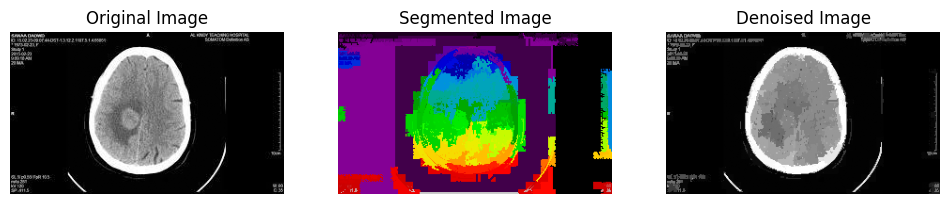

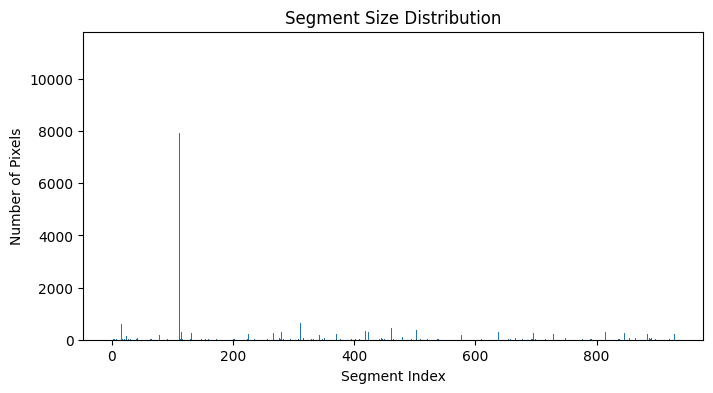

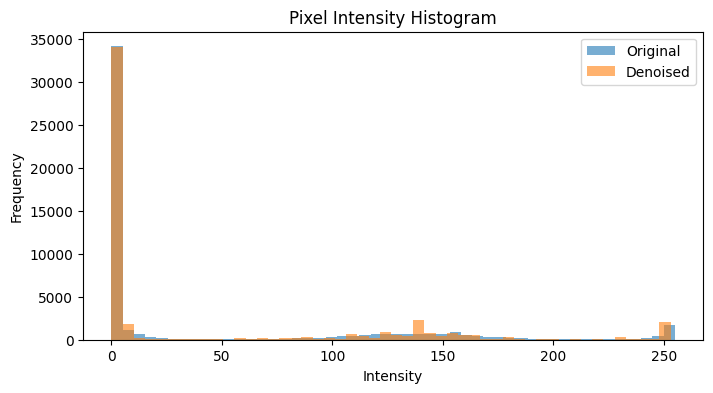

Saved: seg_ct_scan (1).jpeg
Saved: denoise_ct_scan (1).jpeg

Processing: chest_xray (3).jpeg
Number of segments: 6036
MSE: 67.67996132463138
PSNR: 29.826202590122385
Execution time: 3.542011260986328


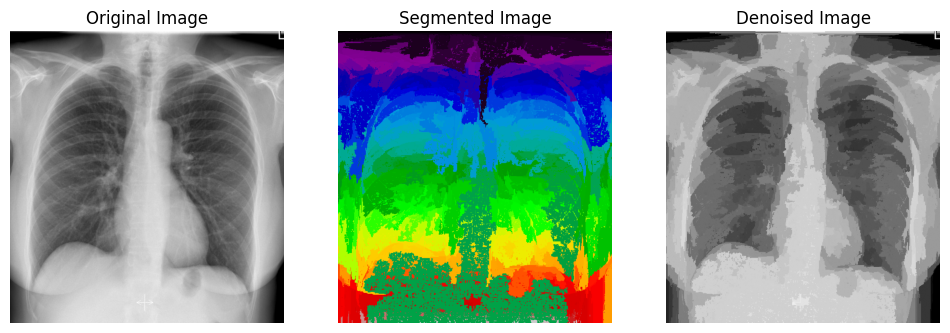

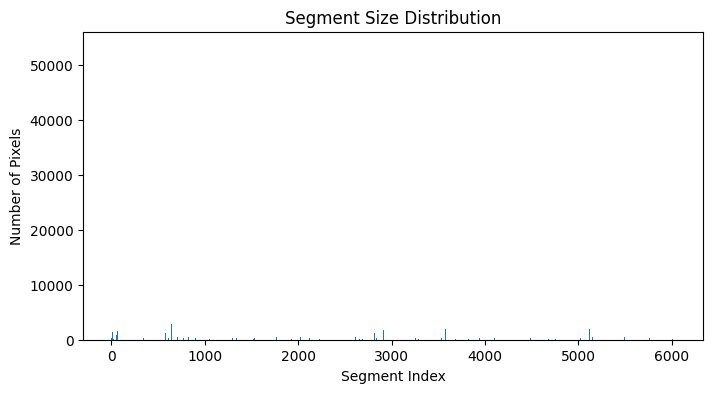

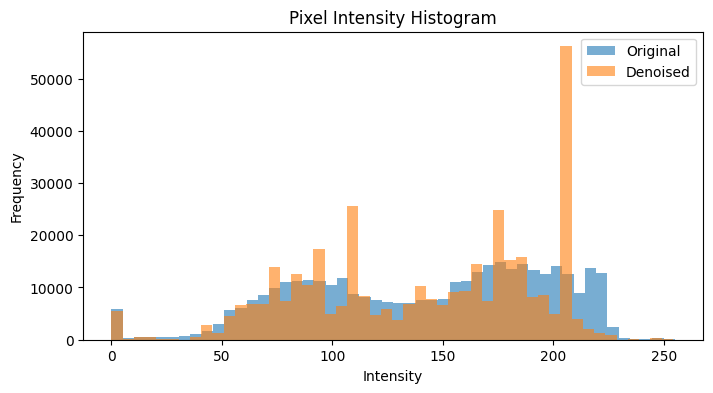

Saved: seg_chest_xray (3).jpeg
Saved: denoise_chest_xray (3).jpeg

Processing: brain_mri (3).png
Number of segments: 2934
MSE: 30.456311102690414
PSNR: 33.29403060842408
Execution time: 3.474374294281006


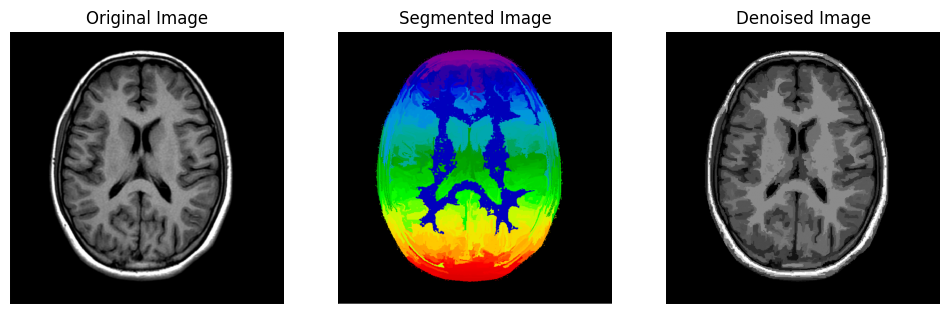

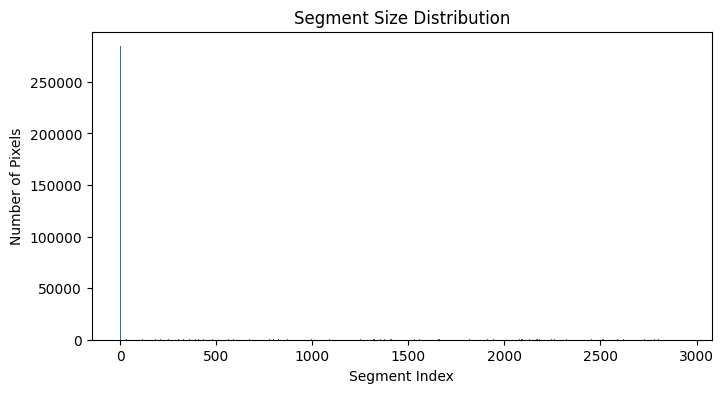

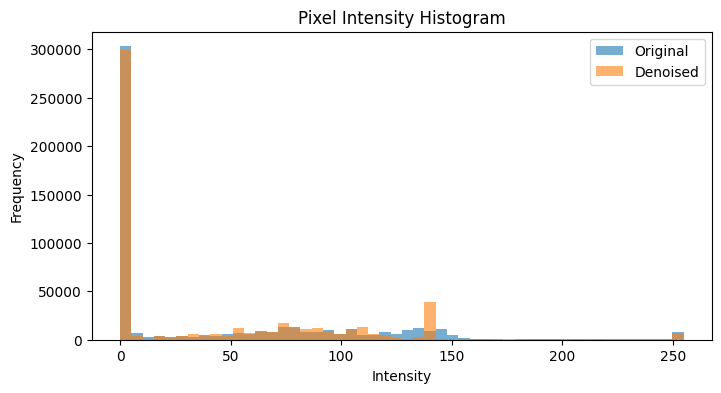

Saved: seg_brain_mri (3).jpeg
Saved: denoise_brain_mri (3).jpeg


In [6]:
# Install required libraries
!pip install scikit-image

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
import time
from google.colab import files
import os

# Upload images from computer
uploaded = files.upload()

# ===============================
# Union-Find Data Structure
# ===============================

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.size = [1]*n
        self.intensity = [0]*n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y, weight, k):
        xroot = self.find(x)
        yroot = self.find(y)

        if xroot == yroot:
            return False

        threshold_x = self.intensity[xroot] + k/self.size[xroot]
        threshold_y = self.intensity[yroot] + k/self.size[yroot]

        if weight <= min(threshold_x, threshold_y):

            if self.size[xroot] < self.size[yroot]:
                xroot, yroot = yroot, xroot

            self.parent[yroot] = xroot
            self.size[xroot] += self.size[yroot]
            self.intensity[xroot] = max(self.intensity[xroot], weight)

            return True

        return False


# ===============================
# Build Graph
# ===============================

def build_graph(image):

    edges = []
    h, w = image.shape

    for i in range(h):
        for j in range(w):

            idx = i*w + j

            if i < h-1:
                weight = abs(int(image[i,j]) - int(image[i+1,j]))
                edges.append((idx, idx+w, weight))

            if j < w-1:
                weight = abs(int(image[i,j]) - int(image[i,j+1]))
                edges.append((idx, idx+1, weight))

    return edges


# ===============================
# Image Segmentation
# ===============================

def segment_image(image, k=300):

    h, w = image.shape
    n = h*w

    edges = build_graph(image)
    edges.sort(key=lambda x: x[2])

    uf = UnionFind(n)

    for u,v,weight in edges:
        uf.union(u,v,weight,k)

    segments = np.zeros(n)

    for i in range(n):
        segments[i] = uf.find(i)

    return segments.reshape(h,w)


# ===============================
# Denoising
# ===============================

def denoise_image(image, segments):

    unique_segments = np.unique(segments)
    denoised = np.zeros_like(image)

    for seg in unique_segments:
        mask = segments == seg
        mean_val = np.mean(image[mask])
        denoised[mask] = mean_val

    return denoised


# ===============================
# Metrics
# ===============================

def compute_metrics(original, denoised):

    mse = np.mean((original - denoised)**2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(255 / np.sqrt(mse))

    return mse, psnr


# ===============================
# Process Uploaded Images
# ===============================

for filename in uploaded.keys():

    print("\nProcessing:", filename)

    image = io.imread(filename)

    # Convert to grayscale if needed
    if len(image.shape) == 3:
        image = color.rgb2gray(image)
        image = (image*255).astype(np.uint8)

    start = time.time()

    segments = segment_image(image)

    denoised = denoise_image(image, segments)

    end = time.time()

    mse, psnr = compute_metrics(image, denoised)

    print("Number of segments:", len(np.unique(segments)))
    print("MSE:", mse)
    print("PSNR:", psnr)
    print("Execution time:", end-start)

    # ===============================
    # Display Images
    # ===============================

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(image, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Segmented Image")
    plt.imshow(segments, cmap='nipy_spectral')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Denoised Image")
    plt.imshow(denoised, cmap='gray')
    plt.axis("off")

    plt.show()


    # ===============================
    # SEGMENTATION HISTOGRAM
    # ===============================

    segment_ids, counts = np.unique(segments, return_counts=True)

    plt.figure(figsize=(8,4))
    plt.title("Segment Size Distribution")
    plt.bar(range(len(counts)), counts)
    plt.xlabel("Segment Index")
    plt.ylabel("Number of Pixels")
    plt.show()


    # ===============================
    # INTENSITY HISTOGRAM
    # ===============================

    plt.figure(figsize=(8,4))
    plt.title("Pixel Intensity Histogram")

    plt.hist(image.flatten(), bins=50, alpha=0.6, label="Original")
    plt.hist(denoised.flatten(), bins=50, alpha=0.6, label="Denoised")

    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()


    # ===============================
    # Save Results (for LaTeX report)
    # ===============================

    base_name, _ = os.path.splitext(filename)

    seg_name = "seg_" + base_name + ".jpeg"
    denoise_name = "denoise_" + base_name + ".jpeg"

    plt.imsave(seg_name, segments, cmap='nipy_spectral')
    plt.imsave(denoise_name, denoised, cmap='gray')

    print("Saved:", seg_name)
    print("Saved:", denoise_name)